# تحلیل نظرات دیجی‌کالا: بازیابی معنایی (RAG) و طبقه‌بندی توصیه‌ی خرید

این نوت‌بوک شامل دو بخش اصلی است:

1. **بازیابی معنایی (Semantic RAG):** یافتن ۲۰ محصول پرنظر، ساخت Embedding از نظرات کاربران با `sentence-transformers`، ایندکس‌گذاری با `FAISS` و بازیابی مرتبط‌ترین نظرات برای چند سؤال اعتبارسنجی مشخص.
2. **طبقه‌بندی توصیه‌ی خرید:** آموزش یک مدل `TF-IDF + LinearSVC` برای پیش‌بینی ستون `recommendation_status` (توصیه می‌شود / نمی‌شود / نظری ندارم) از روی متن نظرات، همراه با تنظیم هایپرپارامتر و تحلیل خطا.


## بخش ۱ — آماده‌سازی و بازیابی معنایی نظرات (RAG)

### ۱.۱ نصب پیش‌نیازها و ایمپورت کتابخانه‌ها

In [1]:
!pip -q install huggingface_hub
!pip install faiss-gpu

import os
import json
import re

import pandas as pd
import numpy as np

from huggingface_hub import hf_hub_download
from sentence_transformers import SentenceTransformer
import faiss


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.2/135.2 MB 13.9 MB/s eta 0:00:0000:0100:01


### ۱.۲ تنظیمات کلی (Config)

In [2]:
REPO_ID = "RadeAI/Digikala_comments_products"
REVISION = "89c3133b169c8d3793db8834f56f32fee33d9db0"

COMMENTS_FILE = "digikala-comments.csv"
PRODUCTS_FILE = "digikala-products.csv"

TOP_N_PRODUCTS = 20          # تعداد محصول برای Validation
RETRIEVAL_TOP_K = 30         # تعداد Candidateهایی که FAISS برمی‌گرداند
FINAL_EVIDENCE_K = 8         # تعداد Evidence نهایی که به API داده می‌شود
MIN_COMMENT_LENGTH = 10

OUTPUT_REQUESTS = "validation_requests.json"
OUTPUT_EVIDENCE_CSV = "validation_evidence.csv"

EMBEDDING_MODEL_NAME = "intfloat/multilingual-e5-base"


### ۱.۳ دانلود دیتاست از Hugging Face

In [3]:
print("Downloading files from Hugging Face...")

comments_path = hf_hub_download(
    repo_id=REPO_ID, filename=COMMENTS_FILE, repo_type="dataset", revision=REVISION
)
products_path = hf_hub_download(
    repo_id=REPO_ID, filename=PRODUCTS_FILE, repo_type="dataset", revision=REVISION
)

print("Done !")
print(comments_path)
print(products_path)


digikala-comments.csv:   0%|          | 0.00/1.28G [00:00<?, ?B/s]

digikala-products.csv:   0%|          | 0.00/259M [00:00<?, ?B/s]

Done !
/root/.cache/huggingface/hub/datasets--RadeAI--Digikala_comments_products/snapshots/89c3133b169c8d3793db8834f56f32fee33d9db0/digikala-comments.csv
/root/.cache/huggingface/hub/datasets--RadeAI--Digikala_comments_products/snapshots/89c3133b169c8d3793db8834f56f32fee33d9db0/digikala-products.csv


### ۱.۴ بارگذاری اطلاعات محصولات

In [4]:
df_products = pd.read_csv(products_path)

print("Products shape:", df_products.shape)
print("\nColumns:")
print(df_products.columns.tolist())


/tmp/ipykernel_58/1942966726.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_products = pd.read_csv(products_path)


Products shape: (1283496, 12)

Columns:
['id', 'title_fa', 'Rate', 'Rate_cnt', 'Category1', 'Category2', 'Brand', 'Price', 'Seller', 'Is_Fake', 'min_price_last_month', 'sub_category']


### ۱.۵ یافتن ۲۰ محصول با بیشترین تعداد نظر

In [5]:
comment_counts = {}
chunksize = 200_000

for chunk in pd.read_csv(comments_path, usecols=["id", "product_id"], chunksize=chunksize):
    counts = chunk["product_id"].value_counts()
    for product_id, count in counts.items():
        comment_counts[product_id] = comment_counts.get(product_id, 0) + int(count)

print("تعداد محصولات دارای comment:", len(comment_counts))

top_products = pd.Series(comment_counts).sort_values(ascending=False).head(TOP_N_PRODUCTS)
top_product_ids = top_products.index.tolist()

print("\nTop 20 products:")
print(top_products)


تعداد محصولات دارای comment: 331599

Top 20 products:
4332510     400
4095187     400
3331597     400
2156856     279
3392906     250
82098       238
4012333     233
5715766     233
7291752     232
715154      221
4545846     221
471187      221
5931403     219
6496858     219
708283      219
4411958     218
126148      218
11788028    218
1518148     217
3447048     217
dtype: int64


### ۱.۶ اطلاعات کامل ۲۰ محصول برتر

In [6]:
top_products_df = df_products[df_products["id"].isin(top_product_ids)].copy()
top_products_df["comment_count"] = top_products_df["id"].map(comment_counts)
top_products_df = top_products_df.sort_values("comment_count", ascending=False)

display(top_products_df[
    ["id", "title_fa", "comment_count", "Rate", "Rate_cnt", "Brand", "Category1", "Category2"]
])


,id,title_fa,comment_count,Rate,Rate_cnt,Brand,Category1,Category2
383809,4095187,برس مژه و ابرو کد BR01ABO,400,82,1487,متفرقه,برس‌ها و تجهیزات آرایشی,برس ها و تجهیزات آرایشی چشم و ابرو
383810,4332510,پیلینگ صورت مدل Eli-74,400,84,2172,متفرقه,برس‌ها و تجهیزات آرایشی,برس ها و تجهیزات آرایشی صورت
383812,3331597,برس ریمل مدل LM02 مجموعه 2 عددی,400,84,587,متفرقه,برس‌ها و تجهیزات آرایشی,برس ها و تجهیزات آرایشی چشم و ابرو
673671,2156856,استیک ضد تعریق زنانه لیدی اسپید مدل invisible ...,279,82,882,لیدی اسپید استیک,ضد تعریق,استیک ضد تعریق
673483,2156856,استیک ضد تعریق زنانه لیدی اسپید مدل invisible ...,279,82,882,لیدی اسپید استیک,ضد تعریق,استیک ضد تعریق
387697,3392906,خمیر دندان ضد حساسیت سیگنال مدل Original وزن 1...,250,82,766,سیگنال,بهداشت دهان و دندان,خمیر دندان
391633,3392906,خمیر دندان ضد حساسیت سیگنال مدل Original وزن 1...,250,82,762,سیگنال,بهداشت دهان و دندان,خمیر دندان
653193,82098,شامپو تقویت کننده و ضد ریزش مو فولیکا حجم 200 ...,238,84,10181,فولیکا,شامپو و مراقبت مو,شامپو مو
664043,82098,شامپو تقویت کننده و ضد ریزش مو فولیکا حجم 200 ...,238,84,10193,فولیکا,شامپو و مراقبت مو,شامپو مو
999336,4012333,تونر پاک کننده صورت لافارر مدل مولتی اکتیو منا...,233,86,10461,لافارر,مراقبت پوست,تونر


### ۱.۷ سؤالات اعتبارسنجی (Validation Questions)

In [7]:
VALIDATION_QUESTIONS = [
    "مردم بیشتر از چه چیزی در این محصول راضی بودند؟",
    "ایرادهای پرتکرار این محصول چیست؟",
    "خریداران درباره‌ی کیفیت این محصول چه گفته‌اند؟",
    "آیا با توجه به تجربه‌ی کاربران ارزش خرید دارد؟",
]

for i, question in enumerate(VALIDATION_QUESTIONS, 1):
    print(f"{i}. {question}")


1. مردم بیشتر از چه چیزی در این محصول راضی بودند؟
2. ایرادهای پرتکرار این محصول چیست؟
3. خریداران درباره‌ی کیفیت این محصول چه گفته‌اند؟
4. آیا با توجه به تجربه‌ی کاربران ارزش خرید دارد؟


### ۱.۸ استخراج نظرات مربوط به ۲۰ محصول برتر

In [8]:
top_product_id_set = set(top_product_ids)

required_columns = [
    "id", "title", "body", "rate", "recommendation_status",
    "product_id", "advantages", "disadvantages", "likes", "dislikes", "is_buyer",
]

top_comments_parts = []

for chunk in pd.read_csv(comments_path, usecols=required_columns, chunksize=chunksize):
    filtered = chunk[chunk["product_id"].isin(top_product_id_set)].copy()
    if len(filtered) > 0:
        top_comments_parts.append(filtered)

df_top_comments = pd.concat(top_comments_parts, ignore_index=True)

print("تعداد comments مربوط به Top 20:")
print(len(df_top_comments))


تعداد comments مربوط به Top 20:
5073


### ۱.۹ پاکسازی متن و ساخت متن نهایی برای Embedding

In [9]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"\s+", " ", text)  # حذف فاصله‌های اضافی
    return text.strip()


text_columns = ["title", "body", "advantages", "disadvantages"]

for column in text_columns:
    df_top_comments[column] = df_top_comments[column].apply(clean_text)

# متنی که برای Embedding استفاده می‌شود
df_top_comments["comment_text"] = (
    "عنوان نظر: " + df_top_comments["title"]
    + " | متن نظر: " + df_top_comments["body"]
    + " | نکات مثبت: " + df_top_comments["advantages"]
    + " | نکات منفی: " + df_top_comments["disadvantages"]
)

df_top_comments = df_top_comments[
    df_top_comments["comment_text"].str.len() >= MIN_COMMENT_LENGTH
].copy()

df_top_comments.reset_index(drop=True, inplace=True)

print("Comments after cleaning:", len(df_top_comments))


Comments after cleaning: 5073


### ۱.۱۰ بارگذاری مدل Embedding

In [10]:
print("Loading embedding model...")

embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

print("Embedding model loaded.")


Loading embedding model...


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Embedding model loaded.


### ۱.۱۱ ساخت Embedding نظرات

In [11]:
comment_texts = df_top_comments["comment_text"].tolist()

print("Creating embeddings for", len(comment_texts), "comments...")

comment_embeddings = embedding_model.encode(
    comment_texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True,
)
comment_embeddings = comment_embeddings.astype("float32")

print("Embedding shape:", comment_embeddings.shape)


Creating embeddings for 5073 comments...


Batches:   0%|          | 0/80 [00:00<?, ?it/s]

Embedding shape: (5073, 768)


### ۱.۱۲ ساخت ایندکس FAISS

In [12]:
embedding_dimension = comment_embeddings.shape[1]

faiss_index = faiss.IndexFlatIP(embedding_dimension)
faiss_index.add(comment_embeddings)

print("FAISS index created.")
print("Number of indexed comments:", faiss_index.ntotal)


FAISS index created.
Number of indexed comments: 5073


### ۱.۱۳ تابع بازیابی معنایی (Semantic Retrieval)

In [13]:
def retrieve_comments(
    product_id,
    question,
    comments_df,
    embedding_model,
    faiss_index,
    top_k=RETRIEVAL_TOP_K,
):
    # فقط comments مربوط به محصول موردنظر
    product_mask = comments_df["product_id"] == product_id
    product_indices = np.where(product_mask.to_numpy())[0]

    if len(product_indices) == 0:
        return pd.DataFrame()

    # Embed کردن سؤال
    query_embedding = embedding_model.encode(
        [question], normalize_embeddings=True, convert_to_numpy=True
    ).astype("float32")

    # جست‌وجو در FAISS — ابتدا تعداد کافی candidate از کل index می‌گیریم
    search_k = min(top_k * 10, faiss_index.ntotal)
    scores, indices = faiss_index.search(query_embedding, search_k)
    scores, indices = scores[0], indices[0]

    # فقط نتایج مربوط به همین product
    product_index_set = set(product_indices.tolist())
    selected_rows = []

    for score, index in zip(scores, indices):
        if index in product_index_set:
            selected_rows.append((index, float(score)))
        if len(selected_rows) >= top_k:
            break

    if len(selected_rows) == 0:
        return pd.DataFrame()

    # ساخت DataFrame نتیجه
    selected_indices = [item[0] for item in selected_rows]
    selected_scores = [item[1] for item in selected_rows]

    retrieved = comments_df.loc[selected_indices].copy()
    retrieved["retrieval_score"] = selected_scores
    retrieved = retrieved.sort_values("retrieval_score", ascending=False)

    return retrieved


### ۱.۱۴ ساخت درخواست‌های اعتبارسنجی (Validation Requests)

In [14]:
validation_requests = []
evidence_rows = []

for _, product in top_products_df.iterrows():
    product_id = product["id"]
    product_title = product["title_fa"]

    print(f"\nProcessing product: {product_title}")

    for question in VALIDATION_QUESTIONS:
        retrieved = retrieve_comments(
            product_id=product_id,
            question=question,
            comments_df=df_top_comments,
            embedding_model=embedding_model,
            faiss_index=faiss_index,
            top_k=RETRIEVAL_TOP_K,
        )

        # فقط Top-K نهایی را برای LLM نگه می‌داریم
        retrieved = retrieved.head(FINAL_EVIDENCE_K)

        evidence = []

        for _, comment in retrieved.iterrows():
            evidence_item = {
                "comment_id": str(comment["id"]),
                "retrieval_score": float(comment["retrieval_score"]),
                "title": comment["title"],
                "body": comment["body"],
                "advantages": comment["advantages"],
                "disadvantages": comment["disadvantages"],
                "rate": None if pd.isna(comment["rate"]) else float(comment["rate"]),
                "recommendation_status": (
                    None if pd.isna(comment["recommendation_status"])
                    else str(comment["recommendation_status"])
                ),
                "likes": None if pd.isna(comment["likes"]) else int(comment["likes"]),
                "dislikes": None if pd.isna(comment["dislikes"]) else int(comment["dislikes"]),
            }
            evidence.append(evidence_item)

            # ردیف مربوط به CSV evidence
            evidence_rows.append({
                "product_id": product_id,
                "product_title": product_title,
                "question": question,
                "comment_id": comment["id"],
                "retrieval_score": comment["retrieval_score"],
                "comment_title": comment["title"],
                "comment_body": comment["body"],
                "advantages": comment["advantages"],
                "disadvantages": comment["disadvantages"],
                "rate": comment["rate"],
                "recommendation_status": comment["recommendation_status"],
                "likes": comment["likes"],
                "dislikes": comment["dislikes"],
            })

        validation_requests.append({
            "product_id": product_id,
            "product_title": product_title,
            "question": question,
            "evidence": evidence,
        })

print("\nTotal validation requests:", len(validation_requests))



Processing product: برس مژه و ابرو کد BR01ABO

Processing product: پیلینگ صورت مدل Eli-74

Processing product: برس ریمل مدل LM02 مجموعه 2 عددی

Processing product: استیک ضد تعریق زنانه لیدی اسپید مدل invisible dry وزن 45 گرم

Processing product: استیک ضد تعریق زنانه لیدی اسپید مدل invisible dry وزن 45 گرم

Processing product: خمیر دندان ضد حساسیت سیگنال مدل Original وزن 100 گرم

Processing product: خمیر دندان ضد حساسیت سیگنال مدل Original وزن 100 گرم

Processing product: شامپو تقویت کننده و ضد ریزش مو فولیکا حجم 200 میلی لیتر

Processing product: شامپو تقویت کننده و ضد ریزش مو فولیکا حجم 200 میلی لیتر

Processing product: تونر پاک کننده صورت لافارر مدل مولتی اکتیو مناسب پوست های چرب و مختلط حجم 170 میلی لیتر

Processing product: فلوئید ضد آفتاب مای مدل Hyaluronic Acid حجم 50 میلی لیتر 

Processing product: تونر پاک کننده صورت لافارر مدل مولتی اکتیو مناسب پوست های چرب و مختلط حجم 170 میلی لیتر

Processing product: فلوئید ضد آفتاب مای مدل Hyaluronic Acid حجم 50 میلی لیتر 

Processing pr

### ۱.۱۵ ذخیره‌سازی خروجی‌ها (JSON + CSV)

In [15]:
with open(OUTPUT_REQUESTS, "w", encoding="utf-8") as f:
    json.dump(validation_requests, f, ensure_ascii=False, indent=2)

print(f"Saved: {OUTPUT_REQUESTS}")


Saved: validation_requests.json


In [16]:
df_evidence = pd.DataFrame(evidence_rows)
df_evidence.to_csv(OUTPUT_EVIDENCE_CSV, index=False, encoding="utf-8-sig")

print(f"Saved: {OUTPUT_EVIDENCE_CSV}")
display(df_evidence.head(20))


Saved: validation_evidence.csv


,product_id,product_title,question,comment_id,retrieval_score,comment_title,comment_body,advantages,disadvantages,rate,recommendation_status,likes,dislikes
0,4095187,برس مژه و ابرو کد BR01ABO,مردم بیشتر از چه چیزی در این محصول راضی بودند؟,53923364,0.834516,,عالی بود راضی بودم,,,5.0,recommended,0,0
1,4095187,برس مژه و ابرو کد BR01ABO,مردم بیشتر از چه چیزی در این محصول راضی بودند؟,53923364,0.834516,,عالی بود راضی بودم,,,5.0,recommended,0,0
2,4095187,برس مژه و ابرو کد BR01ABO,مردم بیشتر از چه چیزی در این محصول راضی بودند؟,53166268,0.833846,راضیم,خوبه نسبت ب قیمت قشنگه,,,4.0,recommended,0,0
3,4095187,برس مژه و ابرو کد BR01ABO,مردم بیشتر از چه چیزی در این محصول راضی بودند؟,53166268,0.833846,راضیم,خوبه نسبت ب قیمت قشنگه,,,4.0,recommended,0,0
4,4095187,برس مژه و ابرو کد BR01ABO,مردم بیشتر از چه چیزی در این محصول راضی بودند؟,46786545,0.831438,خوب بود,راضی بودم,,,4.0,recommended,0,0
5,4095187,برس مژه و ابرو کد BR01ABO,مردم بیشتر از چه چیزی در این محصول راضی بودند؟,46786545,0.831438,خوب بود,راضی بودم,,,4.0,recommended,0,0
6,4095187,برس مژه و ابرو کد BR01ABO,مردم بیشتر از چه چیزی در این محصول راضی بودند؟,46026832,0.831301,,مثل تصویر بود راضی بودم,,,4.0,recommended,0,0
7,4095187,برس مژه و ابرو کد BR01ABO,مردم بیشتر از چه چیزی در این محصول راضی بودند؟,46026832,0.831301,,مثل تصویر بود راضی بودم,,,4.0,recommended,0,0
8,4095187,برس مژه و ابرو کد BR01ABO,ایرادهای پرتکرار این محصول چیست؟,46353115,0.838402,برس مژه و ابرو,خرید این محصول رو پیشنهاد میکنم,['خوب'],,4.0,NaN,0,0
9,4095187,برس مژه و ابرو کد BR01ABO,ایرادهای پرتکرار این محصول چیست؟,46353115,0.838402,برس مژه و ابرو,خرید این محصول رو پیشنهاد میکنم,['خوب'],,4.0,NaN,0,0


## بخش ۲ — طبقه‌بندی وضعیت توصیه‌ی خرید (Recommendation Classifier)

### ۲.۱ بررسی ستون `recommendation_status`

In [17]:
print("Columns in comments dataset:")
print(list(pd.read_csv(comments_path, nrows=0).columns))


Columns in comments dataset:
['id', 'title', 'body', 'created_at', 'rate', 'recommendation_status', 'is_buyer', 'product_id', 'advantages', 'disadvantages', 'likes', 'dislikes', 'seller_title', 'seller_code', 'true_to_size_rate']


In [18]:
label_counts = pd.read_csv(
    comments_path, usecols=["recommendation_status"]
)["recommendation_status"].value_counts(dropna=False)

print(label_counts)


recommendation_status
recommended        4162839
NaN                 894426
no_idea             594121
not_recommended     504903
Name: count, dtype: int64


### ۲.۲ نمونه‌گیری متوازن از کلاس‌ها (Balanced Sampling)

In [19]:
CLASSIFICATION_CHUNKSIZE = 200_000
TARGET_SAMPLES_PER_CLASS = 40_000

VALID_LABELS = {"recommended", "not_recommended", "no_idea"}

CLASSIFICATION_COLUMNS = [
    "id", "title", "body", "recommendation_status", "advantages", "disadvantages", "product_id",
]

class_samples = {"recommended": [], "not_recommended": [], "no_idea": []}
class_counts = {"recommended": 0, "not_recommended": 0, "no_idea": 0}

# خواندن فایل به‌صورت Chunk و نمونه‌گیری جداگانه از هر کلاس
for chunk in pd.read_csv(
    comments_path, usecols=CLASSIFICATION_COLUMNS, chunksize=CLASSIFICATION_CHUNKSIZE
):
    chunk = chunk[chunk["recommendation_status"].isin(VALID_LABELS)].copy()
    if len(chunk) == 0:
        continue

    for label in VALID_LABELS:
        remaining = TARGET_SAMPLES_PER_CLASS - class_counts[label]
        if remaining <= 0:
            continue  # سهم این کلاس کامل شده است

        label_chunk = chunk[chunk["recommendation_status"] == label]
        if len(label_chunk) > remaining:
            label_chunk = label_chunk.sample(n=remaining, random_state=42)

        if len(label_chunk) > 0:
            class_samples[label].append(label_chunk)
            class_counts[label] += len(label_chunk)

# ترکیب و مخلوط کردن نمونه‌های همه‌ی کلاس‌ها
df_cls = pd.concat(
    [pd.concat(class_samples[label], ignore_index=True) for label in VALID_LABELS],
    ignore_index=True,
)
df_cls = df_cls.sample(frac=1, random_state=42).reset_index(drop=True)

print("Final sampled distribution:")
print(df_cls["recommendation_status"].value_counts())
print("\nTotal samples:", len(df_cls))


Final sampled distribution:
recommendation_status
recommended        40000
no_idea            40000
not_recommended    40000
Name: count, dtype: int64

Total samples: 120000


### ۲.۳ ساخت متن ورودی مدل

In [20]:
# از تابع clean_text تعریف‌شده در بخش ۱.۹ استفاده می‌کنیم
for column in ["title", "body", "advantages", "disadvantages"]:
    df_cls[column] = df_cls[column].apply(clean_text)

df_cls["text"] = (
    "عنوان نظر: " + df_cls["title"]
    + " | متن نظر: " + df_cls["body"]
    + " | نکات مثبت: " + df_cls["advantages"]
    + " | نکات منفی: " + df_cls["disadvantages"]
)

display(df_cls[["text", "recommendation_status"]].head(10))


,text,recommendation_status
0,عنوان نظر: عالی | متن نظر: سطح پوست را بسیار ن...,recommended
1,عنوان نظر: خیلی گران است | متن نظر: در شگفت ان...,recommended
2,عنوان نظر: عالی | متن نظر: عالی بود | نکات مثب...,recommended
3,عنوان نظر: | متن نظر: رقیق هست و رنگاش اصلا ش...,no_idea
4,عنوان نظر: زنجیر | متن نظر: اندازه همون مقدار ...,no_idea
5,عنوان نظر: اندازه غیرواقعی | متن نظر: سایز XXL...,not_recommended
6,عنوان نظر: | متن نظر: خوبه کادو دادم | نکات م...,no_idea
7,عنوان نظر: خیلی بد | متن نظر: خیلی بد بود باز ...,no_idea
8,عنوان نظر: | متن نظر: قلم خوبی نداره ومن خوشم...,no_idea
9,عنوان نظر: | متن نظر: خوب نیست چون نوشته بود ...,not_recommended


### ۲.۴ حذف نظراتی که متن معنادار کافی ندارند

In [21]:
MIN_TEXT_LENGTH = 10

before_count = len(df_cls)
df_cls = df_cls[df_cls["text"].str.len() >= MIN_TEXT_LENGTH].copy()
df_cls.reset_index(drop=True, inplace=True)
after_count = len(df_cls)

print("Before:", before_count)
print("After:", after_count)
print("Removed:", before_count - after_count)


Before: 120000
After: 120000
Removed: 0


### ۲.۵ بررسی نهایی توزیع کلاس‌ها

In [22]:
print(df_cls["recommendation_status"].value_counts())
print("\nTotal:", len(df_cls))


recommendation_status
recommended        40000
no_idea            40000
not_recommended    40000
Name: count, dtype: int64

Total: 120000


### ۲.۶ تقسیم داده به Train / Validation / Test

In [23]:
from sklearn.model_selection import train_test_split

X = df_cls["text"]
y = df_cls["recommendation_status"]

# 80% Train / 20% موقت
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# بخش موقت -> 10% Validation + 10% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))


Train: 96000
Validation: 12000
Test: 12000


In [24]:
print("========== TRAIN ==========")
print(y_train.value_counts())

print("\n========== VALIDATION ==========")
print(y_val.value_counts())

print("\n========== TEST ==========")
print(y_test.value_counts())


========== TRAIN ==========
recommendation_status
recommended        32000
not_recommended    32000
no_idea            32000
Name: count, dtype: int64

========== VALIDATION ==========
recommendation_status
not_recommended    4000
no_idea            4000
recommended        4000
Name: count, dtype: int64

========== TEST ==========
recommendation_status
no_idea            4000
recommended        4000
not_recommended    4000
Name: count, dtype: int64


### ۲.۷ استخراج ویژگی با TF-IDF

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.95, sublinear_tf=True)

# فقط روی TRAIN یاد می‌گیریم
X_train_tfidf = vectorizer.fit_transform(X_train)

# Validation و Test فقط تبدیل می‌شوند
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)


Train TF-IDF shape: (96000, 76927)
Validation TF-IDF shape: (12000, 76927)
Test TF-IDF shape: (12000, 76927)


### ۲.۸ مدل پایه: LinearSVC

In [26]:
from sklearn.svm import LinearSVC

baseline_model = LinearSVC(C=1.0, class_weight="balanced", random_state=42)
baseline_model.fit(X_train_tfidf, y_train)

print("Baseline model trained successfully.")


Baseline model trained successfully.


In [27]:
from sklearn.metrics import f1_score

val_predictions = baseline_model.predict(X_val_tfidf)
baseline_val_macro_f1 = f1_score(y_val, val_predictions, average="macro")

print("Baseline Validation Macro F1:", round(baseline_val_macro_f1, 4))


Baseline Validation Macro F1: 0.7244


### ۲.۹ تنظیم هایپرپارامتر C

In [28]:
C_VALUES = [0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0]

tuning_results = []

for C in C_VALUES:
    model = LinearSVC(C=C, class_weight="balanced", random_state=42)
    model.fit(X_train_tfidf, y_train)

    val_predictions = model.predict(X_val_tfidf)
    macro_f1 = f1_score(y_val, val_predictions, average="macro")

    tuning_results.append({"C": C, "validation_macro_f1": macro_f1})

tuning_results_df = pd.DataFrame(tuning_results).sort_values(
    "validation_macro_f1", ascending=False
).reset_index(drop=True)

display(tuning_results_df)

best_C = tuning_results_df.iloc[0]["C"]
best_val_macro_f1 = tuning_results_df.iloc[0]["validation_macro_f1"]

print("\nBest C:", best_C)
print("Best Validation Macro F1:", round(best_val_macro_f1, 4))


,C,validation_macro_f1
0,0.10,0.749231
1,0.25,0.741967
2,0.50,0.734436
3,1.00,0.724438
4,2.00,0.711449
5,5.00,0.693432
6,10.00,0.680735



Best C: 0.1
Best Validation Macro F1: 0.7492


### ۲.۱۰ آموزش مدل نهایی

In [29]:
final_model = LinearSVC(C=best_C, class_weight="balanced", random_state=42)
final_model.fit(X_train_tfidf, y_train)

print("Final model trained successfully.")
print("Selected C:", best_C)


Final model trained successfully.
Selected C: 0.1


### ۲.۱۱ ارزیابی نهایی روی مجموعه‌ی Test

In [30]:
test_predictions = final_model.predict(X_test_tfidf)
test_macro_f1 = f1_score(y_test, test_predictions, average="macro")

print("=" * 40)
print("FINAL TEST MACRO F1:", round(test_macro_f1, 4))
print("=" * 40)


FINAL TEST MACRO F1: 0.743


### ۲.۱۲ گزارش طبقه‌بندی (Classification Report)

In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, test_predictions, digits=4))


                 precision    recall  f1-score   support

        no_idea     0.6679    0.5998    0.6320      4000
not_recommended     0.7649    0.8027    0.7834      4000
    recommended     0.7933    0.8350    0.8136      4000

       accuracy                         0.7458     12000
      macro avg     0.7420    0.7458    0.7430     12000
   weighted avg     0.7420    0.7458    0.7430     12000



### ۲.۱۳ ماتریس درهم‌ریختگی (Confusion Matrix)

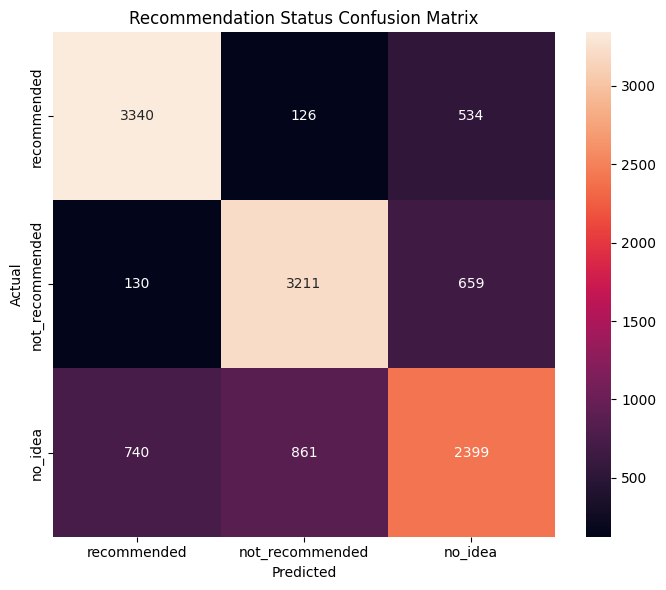

In [32]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

LABELS = ["recommended", "not_recommended", "no_idea"]

cm = confusion_matrix(y_test, test_predictions, labels=LABELS)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=LABELS, yticklabels=LABELS)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Recommendation Status Confusion Matrix")
plt.tight_layout()
plt.show()


### ۲.۱۴ بررسی پیش‌بینی‌های روی داده‌ی Test

In [33]:
df_test_results = pd.DataFrame({
    "text": X_test.values,
    "actual": y_test.values,
    "predicted": test_predictions,
})
df_test_results["correct"] = df_test_results["actual"] == df_test_results["predicted"]

print("Correct:", df_test_results["correct"].sum())
print("Incorrect:", (~df_test_results["correct"]).sum())

display(df_test_results.head(20))


Correct: 8950
Incorrect: 3050


,text,actual,predicted,correct
0,عنوان نظر: | متن نظر: خوبه بد نیست | نکات مثب...,no_idea,no_idea,True
1,عنوان نظر: | متن نظر: بسته بندی عالی داشت و د...,recommended,recommended,True
2,عنوان نظر: | متن نظر: خیلی شکننده است | نکات ...,not_recommended,no_idea,False
3,عنوان نظر: | متن نظر: نه چندان خوب | نکات مثب...,no_idea,no_idea,True
4,عنوان نظر: | متن نظر: کتاب خیلی خوبیه. توصیه ...,recommended,recommended,True
5,عنوان نظر: | متن نظر: به نسب قیمت بد نیست ، ب...,no_idea,no_idea,True
6,عنوان نظر: کتاب تاریخ فرهنگ تمدن روم | متن نظر...,recommended,recommended,True
7,عنوان نظر: گول ظاهرش نخورین آشغاله | متن نظر: ...,not_recommended,not_recommended,True
8,عنوان نظر: | متن نظر: معمولی | نکات مثبت: | ...,no_idea,no_idea,True
9,عنوان نظر: قشنگه | متن نظر: نخرید بهتره کارایی...,no_idea,not_recommended,False


### ۲.۱۵ تحلیل خطاها (Error Analysis)

In [34]:
df_errors = df_test_results[~df_test_results["correct"]].copy()

print("Number of errors:", len(df_errors))
display(df_errors.head(30))


Number of errors: 3050


,text,actual,predicted,correct
2,عنوان نظر: | متن نظر: خیلی شکننده است | نکات ...,not_recommended,no_idea,False
9,عنوان نظر: قشنگه | متن نظر: نخرید بهتره کارایی...,no_idea,not_recommended,False
10,عنوان نظر: خوب نی | متن نظر: تحویل به موقه | ن...,no_idea,not_recommended,False
12,عنوان نظر: خوبه | متن نظر: بسته بندیش ضعیف بود...,recommended,no_idea,False
13,عنوان نظر: رنگش به قرمزی میزنه | متن نظر: از ن...,not_recommended,no_idea,False
17,عنوان نظر: | متن نظر: چیزی نبود ک فک میکردم و...,not_recommended,no_idea,False
21,عنوان نظر: | متن نظر: به عنوان ماسک مو خوبه ا...,recommended,no_idea,False
23,عنوان نظر: جالب بود | متن نظر: ممنون از دیجی ک...,no_idea,recommended,False
27,عنوان نظر: پیشی | متن نظر: من برای گربم خریدم ...,no_idea,recommended,False
33,عنوان نظر: | متن نظر: همینو تو داروخانه ها با...,no_idea,recommended,False
